# End-to-end CNN Training Example

This notebook illustrates how to use PyEarthTools pipeline to train a simple machine learning Convolutional Neural Network (CNN) model using the ERA5 lowres dataset.

## CNN project overview. 
The general aim of the machine learning project is to predict the future state of the atmosphere by taking the current, or previous state and predicting a number of hours ahead in time. <br>
We will select specific ERA5 variables in our `data_pipeline` however, feel free to experiment by changing these. 


* **Model input data**: We will use a range of specific ERA5 variables at -1hr as our input features. 
* **Model target data**: We will try and predict these variables at + 5 hours ahead (try changing this to predict further ahead). 




## Set the path to the ERA5lowres archive as an environment variable

Make sure to set the `ERA5LOWRES` environment variable to make the ERA5 low-resolution archive findable on your system. If you dont have the dataset already downloaded, you will need to download the 5.625deg ERA5 dataset from Weatherbench. Instructions to do so can be found in the `Downloading_ERA5.ipynb` notebook.

Using the %run magic command we can run `Project_config.ipynb` from within our current notebook and access its variables. The follwowing code will run the `Project_config.ipynb` notebook, where the user should have already set set the ERA5LOWRES environment variable and the PROJECT_HOME variable. If you haven't done this, do it now before running the notebook.

- The `ERA5LOWRES` variable is used to set the path to the ERA5 data files
- The `PROJECT_HOME` variable is used to set the path to the project directory

In [12]:
# Uncomment the %run line below. Commented out to allow the documentation site to build correctly.
# If this fails, explicitily set the path to the config notebook e.g. /some/place/where/things/are/notebooks/Project_config.ipynb
#%run ../Project_config.ipynb

## Import packages and set parameters

In [13]:
import sys
from pathlib import Path

import numpy as np
import xarray as xr
import scores
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from lightning import Trainer, LightningModule
from lightning.pytorch.callbacks import RichProgressBar
from rich.progress import track

import pyearthtools.data
import pyearthtools.tutorial
import pyearthtools.pipeline
import pyearthtools.training

In [14]:
# train/validation/test split dates
train_start = "2015-01-01T00"
train_end = "2015-01-12T00"

# Validation data uses the same dates and time, but 1 year after the training data. 
val_start = "2016-01-01T00"
val_end = "2016-01-12T00"

# Test data uses the same dates and time, but 2 years after the training data. 
test_start = "2017-01-01T00"
test_end = "2017-01-12T00"

# number of samples to estimate mean & standard deviation of fields
n_samples = 200

# data loader parameters
batch_size = 1
n_workers = 2

# trainer parameters
max_epochs = 10

## Data Preparation Pipeline
Pipelines can be created with a single call to pyearthtools.pipeline.Pipeline. When we make a call to a Pipeline in a notebook the output is a tabular description of the pipeline, and a graphical ordered representation of the transformations described in the definition of the pipeline.<br>

We will start by setting up a data preparation pipeline that can be used to display data using xarray, then move on to modifying the pipeline to output numpy arrays.

### Xarray 
- In Notebook 2, we demonstrated how to retrieve data using a data preparation pipeline. Here, we will provide a brief reminder on how to do this. <br>

- Additionally, it is useful to display the data structure using Xarray, as it provides a convenient HTML representation of the data. This can help us understand the data format and structure before we convert it to NumPy for further processing.<br>

**Note:** this step isn't necessary for training, but it can be helpful for data exploration and verification.

### Data Preparation Pipeline for Machine Learning

1. Select the variables: "2m_temperature", "u", "v", "geopotential", "vorticity"
2. Sort the variables into the order: "t2", "u", "v", "vorticity", "geopotential"
3. Transform coordinates to ensure longitude values are 0-360 degress (not -180-180 degrees)
4. Flatten the data by the 'level' coordinate.
5. Use TemporalRetrieval to create the:
    * Input data: (-1, 1) tuple is used to select a single timestamp at -1hrs
    * Target data: (6, 1) tuple is used to select a single timestamp at +5hrs ahead. 

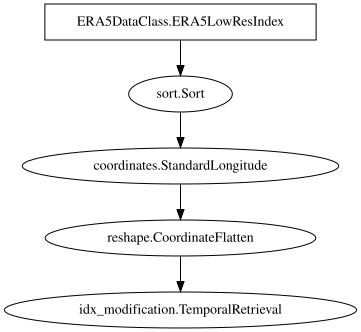

In [15]:
data_preparation = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.archive.era5lowres(["2m_temperature", "u", "v", "geopotential", "vorticity"]),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["t2", "u", "v", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    # retrieve previous/next samples, dt = 1H
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((-1, 1), (6, 1))
    ),
)
data_preparation

### Explanation of Pipeline Steps

The data preparation step retrieves ERA5 low-resolution data for the variables t2m, u, v, geopotential, and vorticity. The data is sorted in the order of v, u, vorticity, and geopotential. The coordinates are standardized to the 0-360° longitude format, and the level coordinate is flattened. The TemporalRetrieval operation retrieves data from 1 hour before to 5 hours after the reference time. For example, if the reference time is train_start, index 0 of the sample contains the input data (T-1), and index 1 contains the output data (T+5).

The input data is used by the model to make predictions, while the output data represents the true values that the model aims to predict.

Full list of steps:

- Extract the variables `["2m_temperature", "u", "v", "geopotential", "vorticity"]` from the era5lowres data.
- Put these variables in a specific order, namely `["t2", "u", "v", "vorticity", "vorticity", "geopotential"]`. Note that not all the variables in the ordering list are in the data; variables in the ordering list that we don't have will be skipped. 
- Change the longitude labels to go from 0->360 degrees instead of -180->180 degrees.
- Sample groups of timesteps for use with recursive forecast training.

### Using the pipeline

To make use of a pipeline object, we simply pass a datetime value to it. This allows the pipeline to process and retrieve the relevant data for the specified datetime.

We asked the data_preparation pipeline to develop 2 datasets for our machine learning project. 
1. Input data of -1hr using the (-1, 1) tuple
2. Target data of +5hr using the (6, 1) tuple


In [16]:
# This code shows how we can pass a date to the data_preparation pipeline and get the corresponding input and target samples.
# We can then index on this object to get the input and target samples using [0] for input samples and [1] for target samples.

input_and_target_samples = data_preparation[train_start]

print("Train start:", train_start)
print("Input sample:", input_and_target_samples[0].time.data)
print("Target sample:", input_and_target_samples[1].time.data)

# Note how the Input sample time is -1hr behind the train start time and the Target sample time is 5hrs ahead of the train start time.

Train start: 2015-01-01T00
Input sample: ['2014-12-31T23:00:00.000000000']
Target sample: ['2015-01-01T05:00:00.000000000']


In [17]:
# We could also split the data into X Input data and y Target data as follows:
print("Train start:", train_start)

X_sample = data_preparation[train_start][0]
print("X_sample:", X_sample.time.data)

y_sample = data_preparation[train_start][1]
print("y_sample:", y_sample.time.data)

Train start: 2015-01-01T00
X_sample: ['2014-12-31T23:00:00.000000000']
y_sample: ['2015-01-01T05:00:00.000000000']


### NumPy Conversion
The following pipeline steps are similar to the previous ones but include additional steps for converting the data to NumPy. This conversion is necessary to prepare the data for ML training.

1. Select the variables: "2m_temperature", "u", "v", "geopotential", "vorticity"
2. Sort the variables into the order: "t2", "u", "v", "vorticity", "geopotential"
3. Transform coordinates to ensure longitude values are 0-360 degress (not -180-180 degrees)
4. Flatten the data by the 'level' coordinate.
5. Use TemporalRetrieval to create the:
    * Input data: (-1, 1) tuple is used to select a single timestamp at -1hrs
    * Target data: (6, 1) tuple is used to select a single timestamp at +5hrs ahead. 

### Additional Steps:
1. Export to a NumPy array.
2. Rearrange the axes of the NumPy array.
3. Remove dimensions of size 1 via a "squeeze" operation.

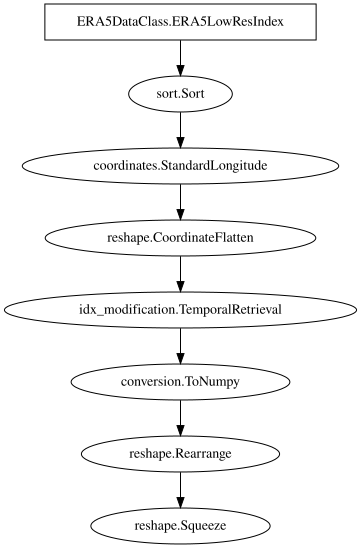

In [18]:
data_preparation = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.archive.era5lowres(["2m_temperature", "u", "v", "geopotential", "vorticity"]),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["t2", "u", "v", "2t", "geopotential", "vorticity"]
    ),
    #FIXME: standard_longitude needs updating to StandardLongitude class.
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    # retrieve previous/next samples, dt = 1H
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((-1, 1), (6, 1))
    ),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
)
data_preparation

We can again provide a datetime to the pipeline to see how it retrieves and processes the corresponding data.<br>
Remember we can index on the sample data. 
* [0] for input data 
* [1] for target data

In [19]:
# Create a sample by passing the data_preparation a datetime. 

sample = data_preparation[train_start]
print("Number of samples:", len(sample))
print("Input data shape:",  sample[0].shape)
print("Target data shape:",  sample[1].shape)

Number of samples: 2
Input data shape: (53, 32, 64)
Target data shape: (53, 32, 64)


### Train/test split

We need to split our data into **training**, **test** and **validation** splits. <br>
We can use the PyEathTools DateRange object to split our data. <br>
We can randomise our training data by chaining the .randomise method.

In [20]:
train_split = pyearthtools.pipeline.iterators.DateRange(train_start, train_end, interval="1h").randomise(seed=42)
train_split

Randomise
	Initialisation                 Wrap around another `Iterator` and randomly sample
		 iterator                       {'DateRange': {'end': "'2015-01-12T00'", 'interval': "'1h'", 'start': "'2015-01-01T00'"}}
		 seed                           42

Lets create another DataRange object for our validation split, but we don't need to randomise this data. 

In [21]:
val_split = pyearthtools.pipeline.iterators.DateRange(val_start, val_end, interval="1h")
val_split

DateRange
	Initialisation                 DateRange Iterator
		 end                            '2016-01-12T00'
		 interval                       '1h'
		 start                          '2016-01-01T00'

In [22]:
print("Train Splits:", train_split[:5])
print("Val Splits:  ", val_split[:5])

Train Splits: (Petdt('2015-01-01T23'), Petdt('2015-01-09T12'), Petdt('2015-01-08T04'), Petdt('2015-01-05T19'), Petdt('2015-01-05T17'))
Val Splits:   (Petdt('2016-01-01T00'), Petdt('2016-01-01T01'), Petdt('2016-01-01T02'), Petdt('2016-01-01T03'), Petdt('2016-01-01T04'))


### Data normalisation

We use approximate mean and standard deviation, computed from only few random samples, to rescale the input/output data to a reasonable range for model training.

In [23]:
%%time
stats_folder = Path('stats_folder')
stats_folder.mkdir(parents=True, exist_ok=True)

mean_path = stats_folder / "mean.npy"
std_path = stats_folder / "std.npy"

# Flag to control whether to recompute mean and std
recompute_stats = False  # Set to True if you want to recompute even if files exist (useful if variables have changed)

# Compute mean/std only if files are missing or if recompute_stats is True
if recompute_stats or not mean_path.is_file() or not std_path.is_file():

    samples = np.stack([data_preparation[train_split[i]][0] for i in range(n_samples)])
    mean_approx = np.mean(samples, axis=0)
    std_approx = np.std(samples, axis=0)
    np.save(mean_path, mean_approx)
    np.save(std_path, std_approx)

CPU times: user 999 μs, sys: 366 μs, total: 1.37 ms
Wall time: 12.7 ms


In [24]:
# Initialise the normaliser with mean and standard deviation paths
normaliser = pyearthtools.pipeline.operations.numpy.normalisation.Deviation(
    mean=mean_path, 
    deviation=std_path, 
    expand=False
)

In [25]:
# Set up the caching mechanism to store processed data in the specified folder with .npy extension
cache_folder = Path('cache_folder')
cache_folder.mkdir(parents=True, exist_ok=True)

caching_step = pyearthtools.pipeline.modifications.Cache(
    cache_folder, 
    pattern_kwargs={'extension': 'npy'},
    # cache_validity='delete'
)

In [26]:
# Initialise the data preparation pipeline with normalization and caching steps
data_preparation_normed = pyearthtools.pipeline.Pipeline(
    data_preparation, 
    normaliser, 
    caching_step
)

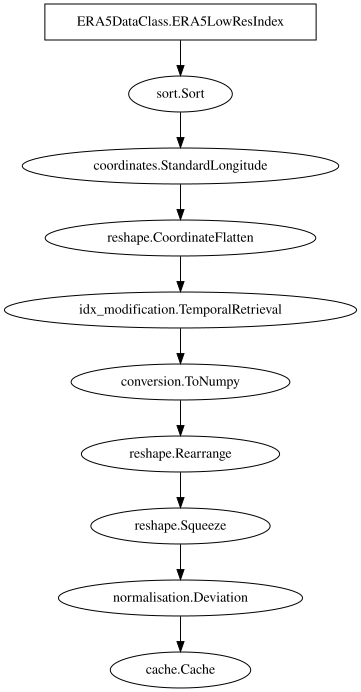

In [27]:
data_preparation_normed

## Model fitting

In [28]:
class CNN(LightningModule):
    def __init__(
        self,
        *,
        n_features: int,
        layer_sizes: list[int],
        dropout: float,
        learning_rate: float,
    ):
        super().__init__()
        self.save_hyperparameters()

        layer_sizes = (n_features,) + tuple(layer_sizes)
        layers = []
        for chan_in, chan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.extend(
                [
                    nn.Conv2d(chan_in, chan_out, kernel_size=3, stride=1, padding=1),
                    nn.ReLU(),
                    nn.Dropout(p=dropout),
                ]
            )
        layers.append(
            nn.Conv2d(layer_sizes[-1], n_features, kernel_size=3, stride=1, padding=1)
        )
        self.cnn = nn.Sequential(*layers)

        self.learning_rate = learning_rate
        self.loss_function = F.l1_loss

    def forward(self, x):
        return self.cnn(x)

    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.loss_function(outputs, targets)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.loss_function(outputs, targets)
        self.log("val_loss", loss)

    def predict_step(self, batch, batch_idx):
        # handle case when data comes from prediction pipeline
        if len(batch) == 2:
            return self(batch[0])
        return self(batch)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return {"optimizer": optimizer}

In [29]:
# Print the shape of the normalised training data for the given start date
print(data_preparation_normed[train_start][0].shape)

# Extract the number of features from the normalised training data
n_features = data_preparation_normed[train_start][0].shape[-3]
print(f"Number of features: {n_features}")

(53, 32, 64)
Number of features: 53


In [30]:
# Define the parameters for the CNN model
model_params = {
    'n_features': n_features,
    'layer_sizes': [64, 64],
    'dropout': 0.6,
    'learning_rate': 1e-5
}

# Initialise the CNN model with the specified parameters
model = CNN(**model_params)

In [31]:
model

CNN(
  (cnn): Sequential(
    (0): Conv2d(53, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Dropout(p=0.6, inplace=False)
    (6): Conv2d(64, 53, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [32]:
# Ensure that we use the CPU even if a GPU is available.
# Uncomment the following line to use your GPU instead.
%env CUDA_VISIBLE_DEVICES=

env: CUDA_VISIBLE_DEVICES=


## Integration With PyTorch Lightning

### The Lightning Data Module
The data module encapsulates all the data-related operations, including:

- **Data Preparation**: Applying the data preparation pipeline to preprocess the data.
- **Data Splitting**: Splitting the data into training and validation sets.
- **Batching**: Creating batches of data for training and validation.
- **Multiprocessing**: Handling data loading in parallel.

The data module integrates seamlessly with PyTorch Lightning, allowing the user to focus on defining their model and training logic without worrying about the data loading and preprocessing details. When one passes the data module to a PyTorch Lightning trainer, it automatically handles the data loading and batching during training and validation.

**Note:** Here we use `forkserver` to prevent deadlocks on Linux platform when using more than one worker in the data loader.



In [33]:
# Initialise the lightning data module for training
data_module = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_preparation_normed,    # Data preparation pipeline
    train_split=train_split,    # Training data split
    valid_split=val_split,      # Validation data split
    batch_size=batch_size,      # Batch size for training
    num_workers=n_workers,      
    multiprocessing_context="forkserver",  
    persistent_workers=True     # Keep workers alive between epochs
)

In [34]:
data_module

PipelineLightningDataModule
	Initialisation                 Pytorch Lightning DataModule.
		 batch_size                     1
		 iterator_dataset               False
		 multiprocessing_context        'forkserver'
		 num_workers                    2
		 persistent_workers             True
		 pipelines                      {'Pipeline': {'__args': '(Pipeline\n\tDescription                    `pyearthtools.pipeline` Data Pipeline\n\n\n\tInitialisation                 \n\t\t exceptions_to_ignore           None\n\t\t iterator                       None\n\t\t sampler                        None\n\tSteps                          \n\t\t ERA5DataClass.ERA5LowResIndex  {\'ERA5LowResIndex\': {\'level_value\': \'None\', \'variables\': "[\'2m_temperature\', \'u\', \'v\', \'geopotential\', \'vorticity\']"}}\n\t\t sort.Sort                      {\'Sort\': {\'order\': "[\'t2\', \'u\', \'v\', \'2t\', \'geopotential\', \'vorticity\']", \'strict\': \'False\'}}\n\t\t coordinates.StandardLongitude  {\'StandardLongitude\': {\'longitude_name\': "\'longitude\'", \'type\': "\'0-360\'"}}\n\t\t reshape.CoordinateFlatten      {\'CoordinateFlatten\': {\'__args\': \'()\', \'coordinate\': "\'level\'", \'skip_missing\': \'False\'}}\n\t\t idx_modification.TemporalRetrieval {\'TemporalRetrieval\': {\'concat\': \'True\', \'delta_unit\': \'None\', \'merge_function\': \'None\', \'merge_kwargs\': \'None\', \'samples\': \'((-1, 1), (6, 1))\'}}\n\t\t conversion.ToNumpy             {\'ToNumpy\': {\'reference_dataset\': \'None\', \'run_parallel\': \'False\', \'saved_records\': \'None\', \'warn\': \'True\'}}\n\t\t reshape.Rearrange              {\'Rearrange\': {\'rearrange\': "\'c t h w -> t c h w\'", \'rearrange_kwargs\': \'None\', \'reverse_rearrange\': \'None\', \'skip\': \'False\'}}\n\t\t reshape.Squeeze                {\'Squeeze\': {\'axis\': \'0\'}}, Deviation\n\tInitialisation                 Deviation Normalisation\n\t\t deviation                      PosixPath(\'stats_folder/std.npy\')\n\t\t expand                         False\n\t\t mean                           PosixPath(\'stats_folder/mean.npy\'), Cache\n\tInitialisation                 An `pyearthtools.pipeline` implementation of the `CachingIndex` from `pyearthtools.data`.\n\t\t cache                          \'/home/548/tjl548/cache_folder\'\n\t\t cache_validity                 \'warn\'\n\t\t pattern                        None\n\t\t pattern_kwargs                 {\'extension\': "\'npy\'"}\n\t\t save_kwargs                    None)', 'exceptions_to_ignore': 'None', 'iterator': 'None', 'sampler': 'None'}}
		 train_split                    {'Randomise': {'iterator': {'DateRange': {'end': "'2015-01-12T00'", 'interval': "'1h'", 'start': "'2015-01-01T00'"}}, 'seed': '42'}}
		 valid_split                    {'DateRange': {'end': "'2016-01-12T00'", 'interval': "'1h'", 'start': "'2016-01-01T00'"}}

In [35]:

checkpoint_dir = Path('checkpoint_dir')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
chkpt_path = Path(checkpoint_dir) / "model.ckpt"

In [36]:
%%time
# Initialise the trainer with the specified parameters
trainer = pyearthtools.training.lightning.Train(
    model,                  # The model to be trained
    data_module,            # The data module for training
    checkpoint_dir,       # Directory to save logs and checkpoints
    max_epochs=max_epochs,  # Maximum number of training epochs
    callbacks=[RichProgressBar()]  # Callbacks for training (e.g., progress bar)
)

# Fit the model
trainer.fit(load=False)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ cnn  │ Sequential │ 98.1 K │ train │
└───┴──────┴────────────┴────────┴───────┘

Trainable params: 98.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 98.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


CPU times: user 1min 29s, sys: 4.67 s, total: 1min 34s
Wall time: 2min 1s


## Predictions

In [46]:
class ReversedPipeline(pyearthtools.pipeline.Pipeline):
    def undo(self, sample):
        return super().apply(sample)

    def apply(self, sample):
        return super().undo(sample)

The code below initialises a reverse_pipeline by extracting specific steps from an existing data_preparation_pipeline. The data_preparation_pipeline is a sequence of data preprocessing steps applied to the input data before it is fed into the model. These steps might include normalisation, reshaping, and other transformations necessary for preparing the data.<br>

In [47]:
# Extract a pipeline used to convert predictions back to the original space
reverse_pipeline = ReversedPipeline(
    *data_preparation_normed.steps[-5:-1]  # Use the last few steps of the data preparation pipeline
)


The ReversedPipeline class is designed to reverse the transformations applied by the original pipeline. By passing `data_preparation_pipeline.steps[-5:-1]` to the `ReversedPipeline` constructor, the code extracts the last few steps (from the fifth-to-last to the second-to-last) of the data_preparation_pipeline.

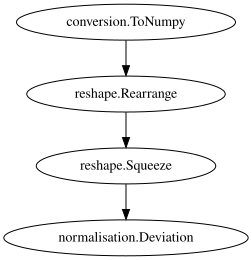

In [48]:
reverse_pipeline

In [49]:
# Wrap the trained model with the data preparation pipeline
model_wrapper = pyearthtools.training.lightning.Predict(
    model,                    # The trained CNN model
    data_preparation_normed # The data preparation pipeline
)

# Initialise the predictor with the model wrapper and reverse pipeline
predictor = pyearthtools.training.predict.Predictor(
    model_wrapper,  # The wrapped model with data preparation steps
    reverse_pipeline # The reverse pipeline to convert predictions back to original space
)

In [50]:
data_preparation_normed[test_start][1]

array([[[ 0.24508621,  0.11092616, -0.03467894, ...,  0.4291155 ,
          0.41032445,  0.34905007],
        [ 0.06729264,  0.22444546,  0.47754756, ...,  0.1731117 ,
          0.1314369 ,  0.07036693],
        [ 0.44198117,  0.65568805,  0.72863257, ..., -0.30857596,
          0.20914252,  0.7002841 ],
        ...,
        [ 0.01560672, -0.1894289 , -0.48232144, ...,  1.0082207 ,
          0.60520154,  0.27669346],
        [-0.3044927 , -0.37066957, -0.27879533, ...,  0.48623183,
          0.23022135, -0.04774872],
        [ 0.51261675,  0.46222374,  0.43611524, ...,  0.784465  ,
          0.67638767,  0.585016  ]],

       [[ 0.1739989 ,  0.14216088,  0.1003792 , ...,  0.23476335,
          0.21560968,  0.19656503],
        [-0.010908  ,  0.13098194,  0.16181199, ...,  0.07339582,
         -0.10057873, -0.16229634],
        [ 1.0853866 ,  1.1272728 ,  1.2927105 , ..., -0.4901738 ,
          0.47894996,  0.6378232 ],
        ...,
        [ 0.32347783,  0.1530604 , -0.36704504, ...,  

In [51]:
%%time 

# Define the test split using a date range with 1-hour intervals
test_split = pyearthtools.pipeline.iterators.DateRange(test_start, test_end, interval="1h")

# Initialise lists to store true values and predictions
y_true = []
y_preds = []

# Iterate over the test dates and process each one
for test_date in track(list(test_split)):
    # Apply the reverse pipeline to get the true values
    y = reverse_pipeline.apply(data_preparation_normed[test_date][1])
    y["time"] = y.time.copy(data=[test_date.datetime64()])
    y_true.append(y)

    # Predict the values using the predictor
    y_pred = predictor.predict(test_date)
    # Add the test date to the predictions
    y_pred["time"] = y_pred.time.copy(data=[test_date.datetime64()])
    y_preds.append(y_pred)

# Concatenate the true values and predictions along the time dimension
y_true = xr.concat(y_true, dim="time")
y_preds = xr.concat(y_preds, dim="time")

Output()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


CPU times: user 8.2 s, sys: 1.74 s, total: 9.94 s
Wall time: 12.9 s


In [52]:
y_preds

<xarray.Dataset> Size: 115MB
Dimensions:    (time: 264, latitude: 32, longitude: 64)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2017-01-01 ... 2017-01-11T23:00:00
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
Data variables: (12/53)
    u50        (time, latitude, longitude) float32 2MB -4.581 -4.335 ... -7.852
    u100       (time, latitude, longitude) float32 2MB -4.623 -4.591 ... -2.559
    u150       (time, latitude, longitude) float32 2MB -4.192 -3.545 ... 0.2567
    u200       (time, latitude, longitude) float32 2MB -4.655 -3.789 ... 4.186
    u250       (time, latitude, longitude) float32 2MB -4.314 -3.777 ... 3.295
    u300       (time, latitude, longitude) float32 2MB -4.055 -2.36 ... 2.989
    ...         ...
    vo500      (time, latitude, longitude) float32 2MB -4.889e-06 ... -7.252e-07
    vo600      (time, latitude, longitude) float32 2MB -5.595e-06 ... -1.638e-05
    vo700      (time, latitude, longitude) float32 2MB 2.061e-05 ... -1.243e-05
    vo850      (time, latitude, longitude) float32 2MB -3.439e-06 ... -3.281e-06
    vo925      (time, latitude, longitude) float32 2MB -1.83e-06 ... -1.325e-05
    vo1000     (time, latitude, longitude) float32 2MB -1.124e-06 ... -1.083e-05
Attributes:
    level-dtype:  int32

Text(0.5, 1.05, 'Predictions')

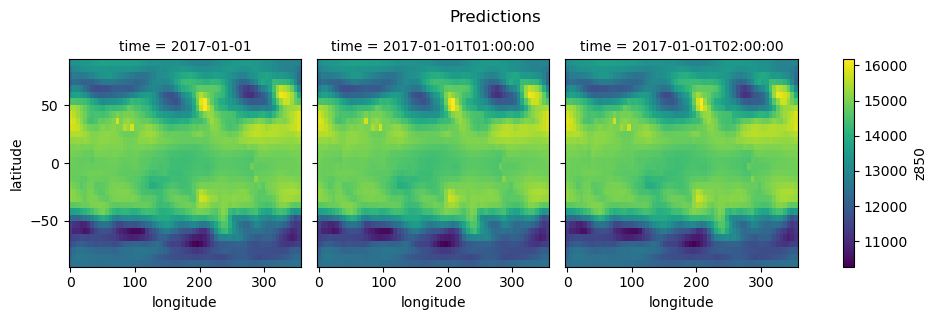

In [53]:
grid = y_preds.isel(time=slice(3))["z850"].plot(col="time")
grid.fig.suptitle("Predictions", y=1.05)

Text(0.5, 1.05, 'Ground truth')

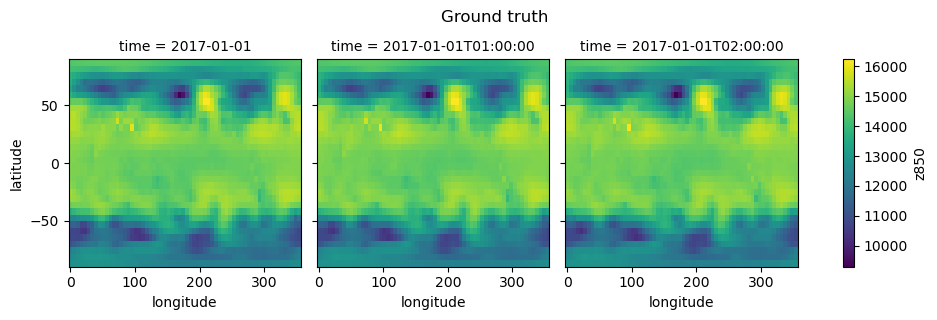

In [54]:
grid = y_true.isel(time=slice(3))["z850"].plot(col="time")
grid.fig.suptitle("Ground truth", y=1.05)

## Evaluation

In [55]:
mae_score = scores.continuous.mae(
    y_preds, y_true, preserve_dims=["latitude", "longitude"]
)

In [56]:
mae_score

<xarray.Dataset> Size: 435kB
Dimensions:    (latitude: 32, longitude: 64)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
Data variables: (12/53)
    u50        (latitude, longitude) float32 8kB 1.198 1.274 ... 12.02 12.39
    u100       (latitude, longitude) float32 8kB 1.133 1.416 ... 6.093 6.112
    u150       (latitude, longitude) float32 8kB 1.642 1.628 ... 3.378 3.009
    u200       (latitude, longitude) float32 8kB 1.731 1.746 ... 1.453 2.182
    u250       (latitude, longitude) float32 8kB 1.953 1.698 ... 2.296 4.05
    u300       (latitude, longitude) float32 8kB 3.514 3.224 ... 3.809 5.691
    ...         ...
    vo500      (latitude, longitude) float32 8kB 1.951e-05 ... 2.748e-05
    vo600      (latitude, longitude) float32 8kB 1.791e-05 ... 2.711e-05
    vo700      (latitude, longitude) float32 8kB 2.741e-05 ... 2.993e-05
    vo850      (latitude, longitude) float32 8kB 9.281e-06 ... 2.576e-05
    vo925      (latitude, longitude) float32 8kB 9.006e-06 ... 2.991e-05
    vo1000     (latitude, longitude) float32 8kB 8.669e-06 ... 1.784e-05
Attributes:
    level-dtype:  int32

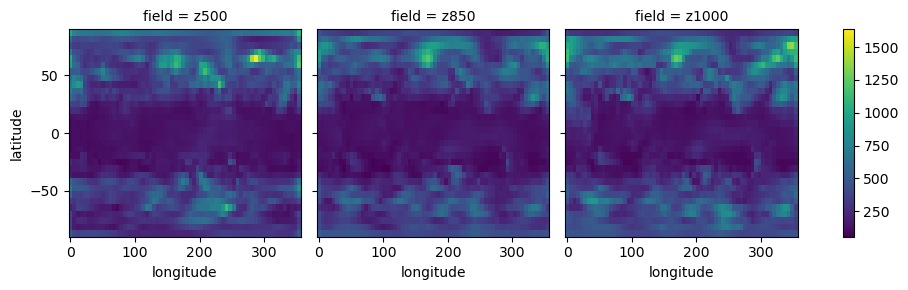

In [57]:
mae_score[["z500", "z850", "z1000"]].to_array(dim="field").plot(col="field")

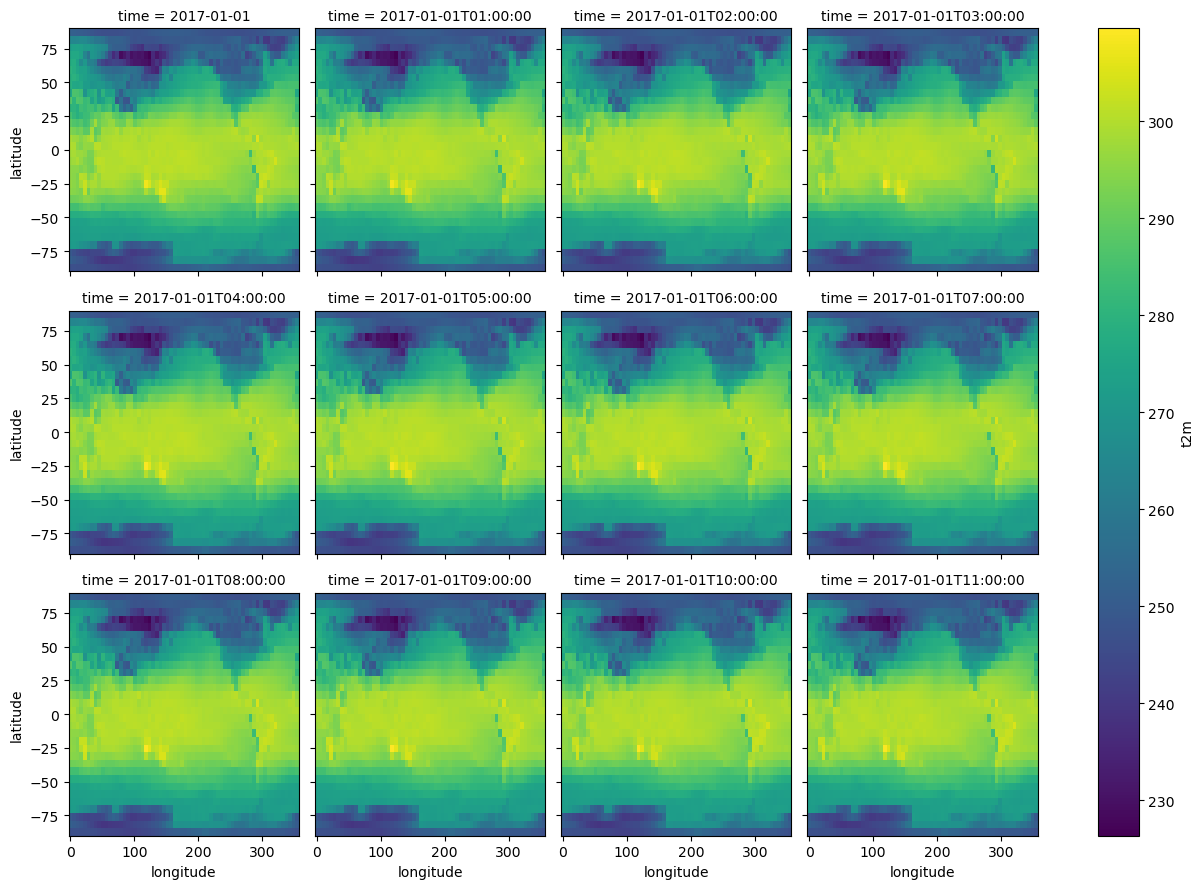

In [62]:
grid = y_preds["t2m"][:12].plot(x='longitude', y='latitude', col="time", col_wrap=4)